In [77]:
## importing all necessary librabries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose


ModuleNotFoundError: No module named 'statsmodels'

In [6]:
##reading weather data
file_path = "/home/home/code/xucenying/grid-intelligence/notebooks/susanta/Energy_price vs weather data/germany_weather.csv"
weather_df=pd.read_csv(file_path)

In [7]:
weather_df.head()

,city,latitude,longitude,timestamp,temperature_c,humidity_percent,cloud_cover_percent,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2
0,Berlin,52.52,13.41,2014-01-01T00:00,-0.3,94,24,0.0,0.0,0.0
1,Berlin,52.52,13.41,2014-01-01T01:00,-0.3,94,53,0.0,0.0,0.0
2,Berlin,52.52,13.41,2014-01-01T02:00,-0.3,94,82,0.0,0.0,0.0
3,Berlin,52.52,13.41,2014-01-01T03:00,-0.2,94,82,0.0,0.0,0.0
4,Berlin,52.52,13.41,2014-01-01T04:00,-0.1,94,97,0.0,0.0,0.0


In [64]:
weather_berlin_df = weather_df[weather_df['city'] == "Berlin"]
weather_berlin_df.head()

,city,latitude,longitude,timestamp,temperature_c,humidity_percent,cloud_cover_percent,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2
0,Berlin,52.52,13.41,2014-01-01T00:00,-0.3,94,24,0.0,0.0,0.0
1,Berlin,52.52,13.41,2014-01-01T01:00,-0.3,94,53,0.0,0.0,0.0
2,Berlin,52.52,13.41,2014-01-01T02:00,-0.3,94,82,0.0,0.0,0.0
3,Berlin,52.52,13.41,2014-01-01T03:00,-0.2,94,82,0.0,0.0,0.0
4,Berlin,52.52,13.41,2014-01-01T04:00,-0.1,94,97,0.0,0.0,0.0


<Axes: xlabel='timestamp'>

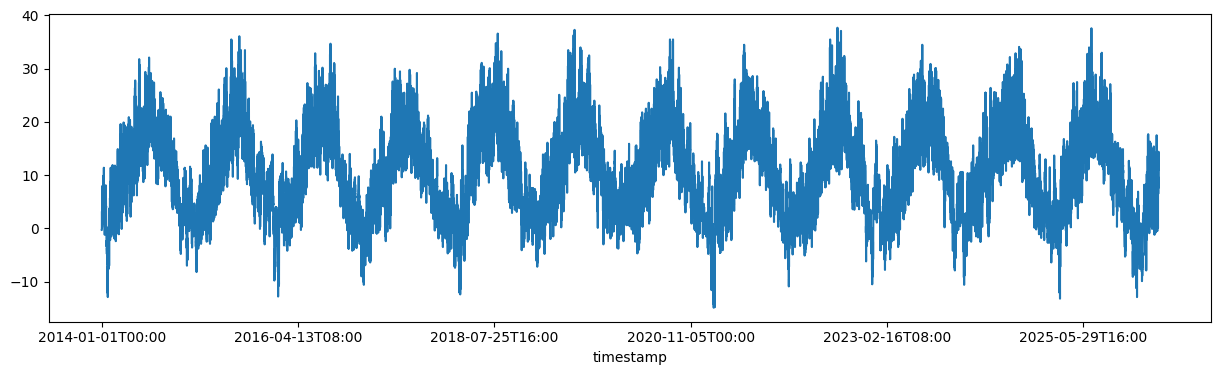

In [84]:
weather_berlin_df.set_index("timestamp")["temperature_c"].plot(figsize=(15,4))


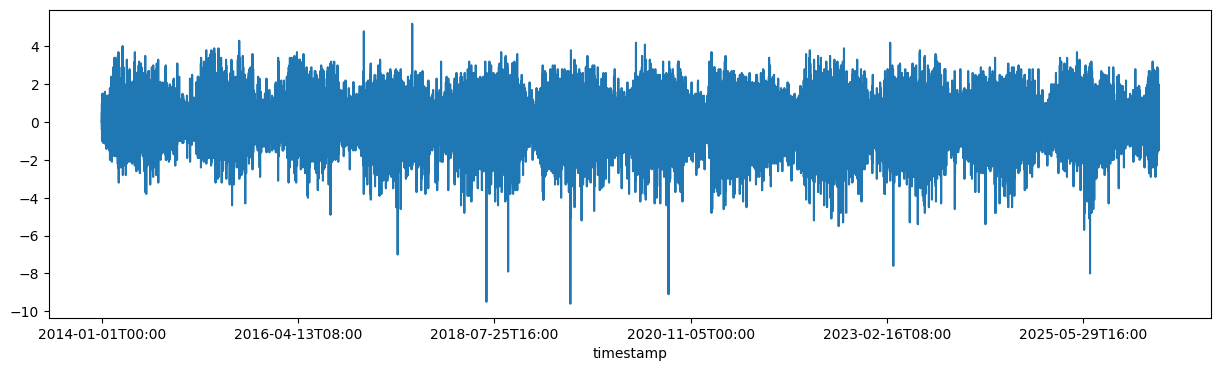

In [78]:
weather_berlin_df.set_index("timestamp")["temperature_c"].diff().plot(figsize=(15,4));

In [55]:
weather_df.isna().sum()

city                       0
latitude                   0
longitude                  0
timestamp                  0
temperature_c              0
humidity_percent           0
cloud_cover_percent        0
shortwave_radiation_wm2    0
direct_radiation_wm2       0
diffuse_radiation_wm2      0
dtype: int64

In [19]:
##reading combined csv files for energy_price
file_path_energy = "/home/home/code/xucenying/grid-intelligence/notebooks/susanta/Energy_price vs weather data/combined_energy_price_cleaned.csv"
energy_df = pd.read_csv(file_path_energy, sep="\t")

/tmp/ipykernel_75479/2191306532.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  energy_df = pd.read_csv(file_path_energy, sep="\t")


In [20]:
energy_df.head(5)

,InstanceCode,DateTime(UTC),ResolutionCode,AreaDisplayName,Sequence,Price[Currency/MWh],UpdateTime(UTC)
0,1a9fda3d76f57dbd387b15e545ae3de5,2015-01-04 23:00:00,PT60M,DE-AT-LU,,22.34,2024-10-03 13:21:54
1,1a9fda3d76f57dbd387b15e545ae3de5,2015-01-05 00:00:00,PT60M,DE-AT-LU,,17.93,2024-10-03 13:21:54
2,1a9fda3d76f57dbd387b15e545ae3de5,2015-01-05 01:00:00,PT60M,DE-AT-LU,,15.17,2024-10-03 13:21:54
3,1a9fda3d76f57dbd387b15e545ae3de5,2015-01-05 02:00:00,PT60M,DE-AT-LU,,16.38,2024-10-03 13:21:54
4,1a9fda3d76f57dbd387b15e545ae3de5,2015-01-05 03:00:00,PT60M,DE-AT-LU,,17.38,2024-10-03 13:21:54


In [35]:
energy_df.shape


(378307, 7)

In [21]:
energy_df.keys()

Index(['InstanceCode', 'DateTime(UTC)', 'ResolutionCode', 'AreaDisplayName',
       'Sequence', 'Price[Currency/MWh]', 'UpdateTime(UTC)'],
      dtype='object')

In [23]:
X = energy_df["DateTime(UTC)"] 
y = energy_df["Price[Currency/MWh]"] 

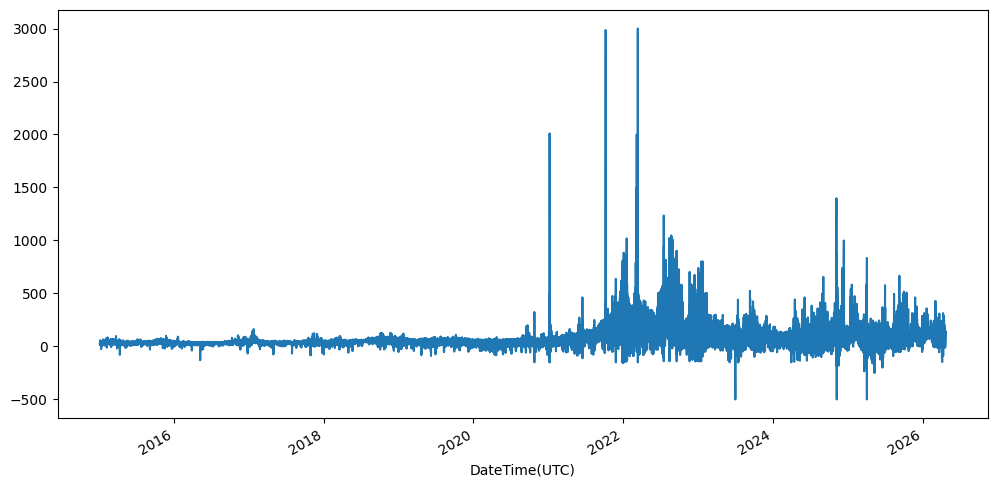

In [25]:
energy_df["DateTime(UTC)"] = pd.to_datetime(energy_df["DateTime(UTC)"])
energy_df.set_index("DateTime(UTC)")["Price[Currency/MWh]"].plot(figsize=(12,6))
plt.show()

In [28]:
energy_df["DateTime(UTC)"]

0        2015-01-04 23:00:00
1        2015-01-05 00:00:00
2        2015-01-05 01:00:00
3        2015-01-05 02:00:00
4        2015-01-05 03:00:00
                 ...        
378302   2026-04-21 20:45:00
378303   2026-04-21 21:00:00
378304   2026-04-21 21:15:00
378305   2026-04-21 21:30:00
378306   2026-04-21 21:45:00
Name: DateTime(UTC), Length: 378307, dtype: datetime64[ns]

In [30]:
type(energy_df["DateTime(UTC)"])

pandas.core.series.Series

In [43]:
df_2025 = energy_df[energy_df["DateTime(UTC)"].dt.year == 2025]
df_2025.tail()

,InstanceCode,DateTime(UTC),ResolutionCode,AreaDisplayName,Sequence,Price[Currency/MWh],UpdateTime(UTC)
357174,e0eec9f40632e9a66634803a4572a2e2,2025-12-31 23:15:00,PT15M,DE-LU,1,61.48,2025-12-31 12:55:08
357175,8e2819009ba367acae485984e26d25bf,2025-12-31 23:30:00,PT15M,DE-LU,2,63.00,2025-12-30 10:07:37
357176,e0eec9f40632e9a66634803a4572a2e2,2025-12-31 23:30:00,PT15M,DE-LU,1,58.00,2025-12-31 12:55:08
357177,8e2819009ba367acae485984e26d25bf,2025-12-31 23:45:00,PT15M,DE-LU,2,41.08,2025-12-30 10:07:37
357178,e0eec9f40632e9a66634803a4572a2e2,2025-12-31 23:45:00,PT15M,DE-LU,1,49.99,2025-12-31 12:55:08


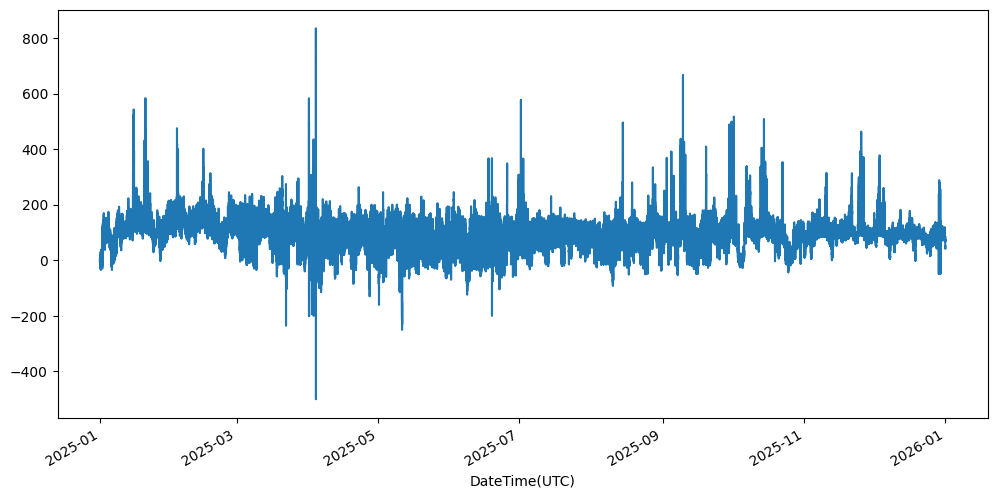

In [42]:
df_2025 = energy_df[energy_df["DateTime(UTC)"].dt.year == 2025]
df_2025.set_index("DateTime(UTC)")["Price[Currency/MWh]"].plot(figsize=(12,6))
plt.show()

In [52]:
year_list = np.arange(2015, 2027, 1)
year_list

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025,
       2026])

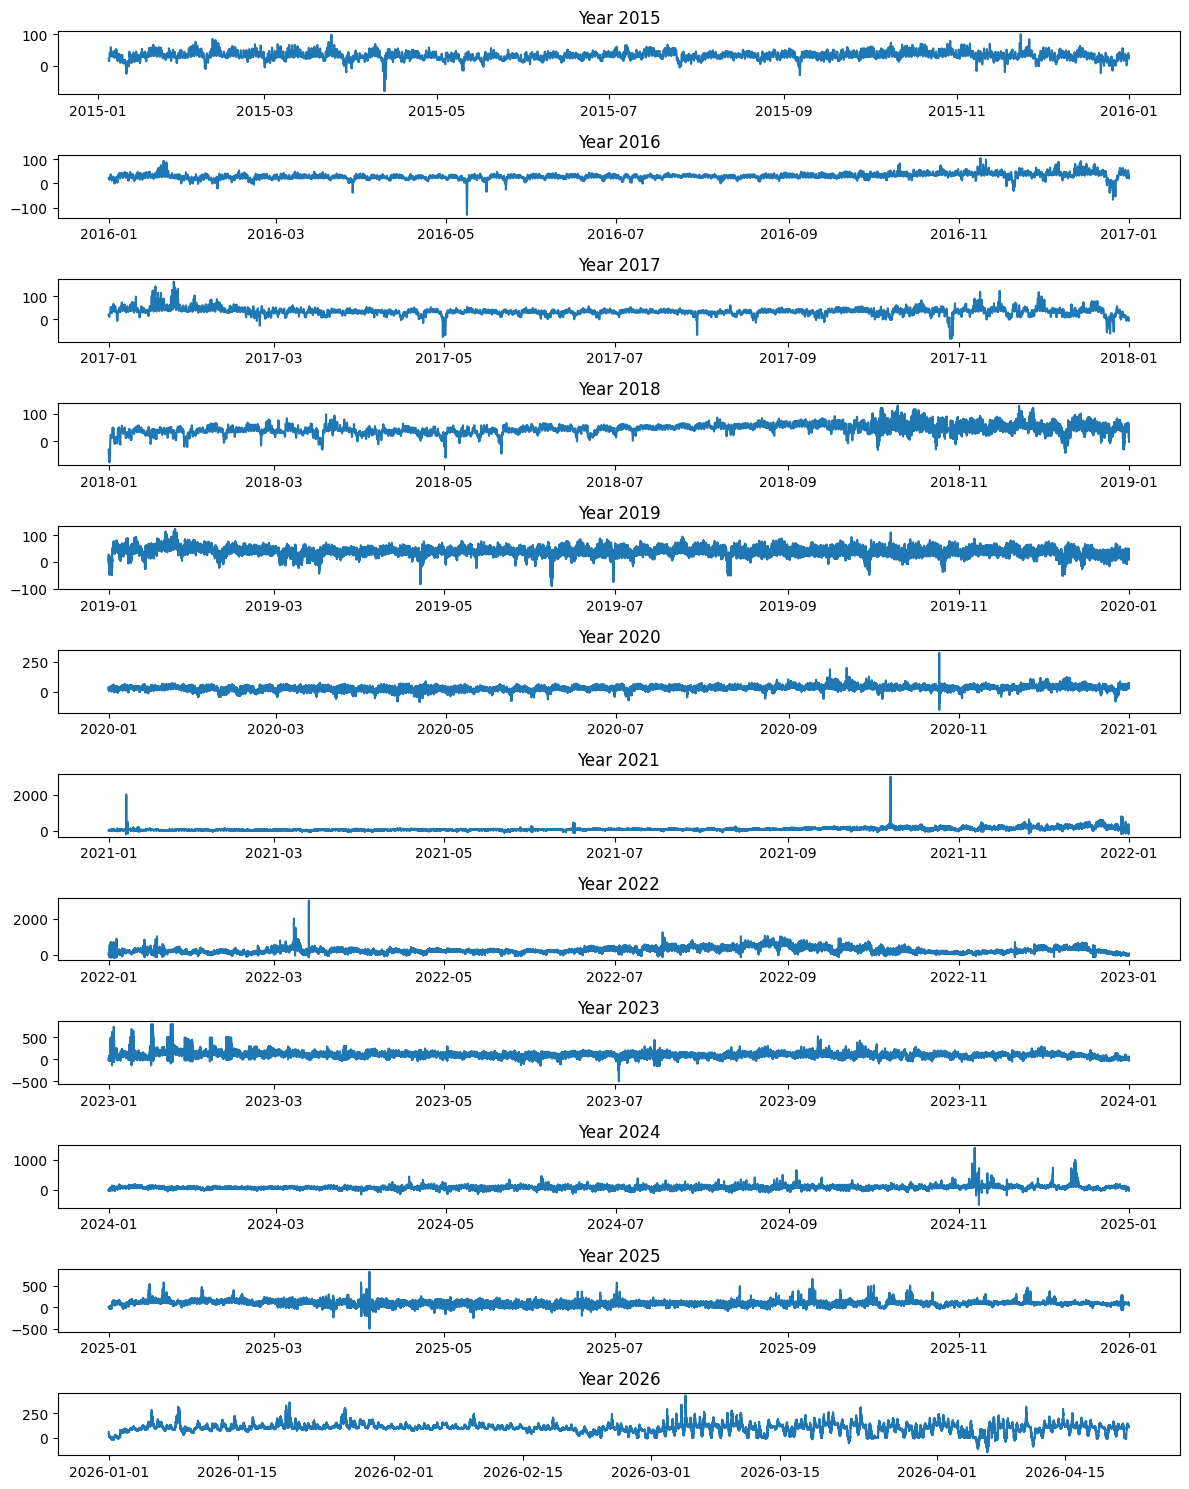

In [53]:
plt.figure(figsize=(12,15))

for idx, year in enumerate(year_list, 1):
    df_i = energy_df[energy_df["DateTime(UTC)"].dt.year == year]
    
    plt.subplot(len(year_list), 1, idx)
    plt.plot(df_i["DateTime(UTC)"], df_i["Price[Currency/MWh]"])
    plt.title(f"Year {year}")
    

plt.tight_layout()
plt.show()

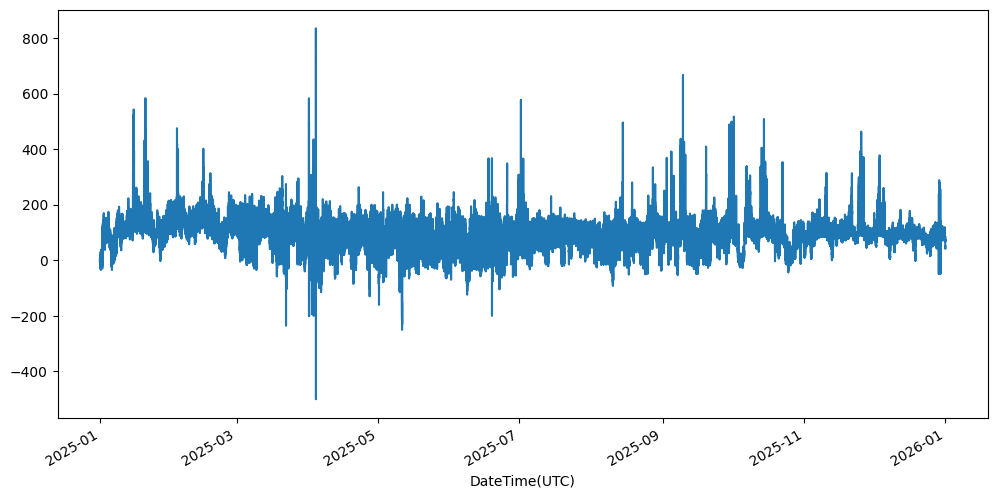

In [81]:
df_2025 = energy_df[energy_df["DateTime(UTC)"].dt.year == 2025]
df_2025.set_index("DateTime(UTC)")["Price[Currency/MWh]"].plot(figsize=(12,6))
plt.show()